# 01 — Source: External метрики (Trends + Wikipedia + temporal)

## 0. Контекст

**Источники данных:**
- **Google Trends** (`pytrends`): индекс поисковых запросов "puzzle game" по дням, шкала 0–100.
- **Wikipedia Pageviews API**: дневные просмотры статьи "Puzzle video game" — proxy интереса к теме.
- **Temporal**: `seasonality_change` — изменение недельной скользящей средней (производная от DAU/installs каждого продукта).

**6 колонок External-группы:**

| Колонка | Описание |
|---|---|
| market_trend | Google Trends интерес к "puzzle game" (0–100) |
| media_coverage | Дневные просмотры Wikipedia (счётчик) |
| market_sentiment | Композитный z-score настроения рынка |
| media_coverage_ma7 | Скользящее среднее media_coverage (7 дней) |
| media_coverage_change | Изменение media_coverage день-к-дню |
| seasonality_change | Недельная скользящая производная (app-specific) |

⚠️ **Особенность:** первые 5 колонок (`market_trend`, `media_coverage`, `market_sentiment`, `media_coverage_ma7`, `media_coverage_change`) **идентичны** для f1 и f2 — общий тренд категории.
`seasonality_change` — **app-specific**: производная от DAU/installs конкретного продукта. Это будет программно проверено в §1.

**Следствие:** macro-сигналы (Trends + Wikipedia) не различают продукты. `seasonality_change` различает — но лишь отражает динамику каждого приложения.

**Гипотеза:** external-сигналы могут улавливать всплески интереса (вирусные посты, сезонные пики), влиявшие на установки/retention обоих продуктов одновременно. `seasonality_change` — дополнительный лаговый сигнал о ритме аудитории.

In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup,
    split_by_app, top_correlated_pairs, check_inf_columns,
    assert_shared_columns,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "01_source_external"
df = load_dataset()
print(f"Dataset: {df.shape}")

Dataset: (222, 60)


In [2]:
EXTERNAL_COLS = [
    "market_trend", "media_coverage",
    "market_sentiment", "media_coverage_ma7", "media_coverage_change",
    "seasonality_change",
]
assert len(EXTERNAL_COLS) == 6
print(f"EXTERNAL_COLS: {len(EXTERNAL_COLS)} колонок")

EXTERNAL_COLS: 6 колонок


## 1. Загрузка и подтверждение идентичности

In [3]:
df_f1, df_f2 = split_by_app(df)
print(f"Flood-It!   shape: {df_f1.shape}")
print(f"Flood-It! 2 shape: {df_f2.shape}")
print()

# 5 shared columns (macro external signals)
SHARED_COLS = [
    "market_trend", "media_coverage",
    "market_sentiment", "media_coverage_ma7", "media_coverage_change",
]
assert_shared_columns(df_f1, df_f2, SHARED_COLS)
print(f"✓ Все {len(SHARED_COLS)} macro-external-колонок идентичны для f1 и f2")
for col in SHARED_COLS:
    print(f"  {col}: f1 == f2 → True")

# seasonality_change is app-specific — verified programmatically
sc_same = (
    df_f1["seasonality_change"].fillna(-9999.0).reset_index(drop=True)
    == df_f2["seasonality_change"].fillna(-9999.0).reset_index(drop=True)
).all()
print(f"\nseasonality_change: f1 == f2 → {sc_same}  (app-specific — производная DAU/installs)")

# Working dataset: shared macro cols + seasonality_change for each app
df_external_shared = df_f1[["date"] + SHARED_COLS].copy().reset_index(drop=True)
df_external_shared["seasonality_change_f1"] = df_f1["seasonality_change"].values
df_external_shared["seasonality_change_f2"] = df_f2["seasonality_change"].values
print(f"\ndf_external_shared shape: {df_external_shared.shape}")
print("  (5 shared macro cols + seasonality_change для f1 и f2 раздельно)")

Flood-It!   shape: (111, 60)
Flood-It! 2 shape: (111, 60)

✓ Все 5 macro-external-колонок идентичны для f1 и f2
  market_trend: f1 == f2 → True
  media_coverage: f1 == f2 → True
  market_sentiment: f1 == f2 → True
  media_coverage_ma7: f1 == f2 → True
  media_coverage_change: f1 == f2 → True

seasonality_change: f1 == f2 → False  (app-specific — производная DAU/installs)

df_external_shared shape: (111, 8)
  (5 shared macro cols + seasonality_change для f1 и f2 раздельно)


## 2. Качество данных

In [4]:
# NaN counts
nan_f1 = df_f1[EXTERNAL_COLS].isna().sum().rename("NaN_count_f1")
nan_f2 = df_f2[EXTERNAL_COLS].isna().sum().rename("NaN_count_f2")
missing_summary = pd.concat([nan_f1, nan_f2], axis=1)
missing_summary["pct_f1"] = (missing_summary["NaN_count_f1"] / len(df_f1) * 100).round(1)
display(missing_summary.sort_values("NaN_count_f1", ascending=False))

,NaN_count_f1,NaN_count_f2,pct_f1
media_coverage_change,1,1,0.9
seasonality_change,1,1,0.9
media_coverage,0,0,0.0
market_trend,0,0,0.0
media_coverage_ma7,0,0,0.0
market_sentiment,0,0,0.0


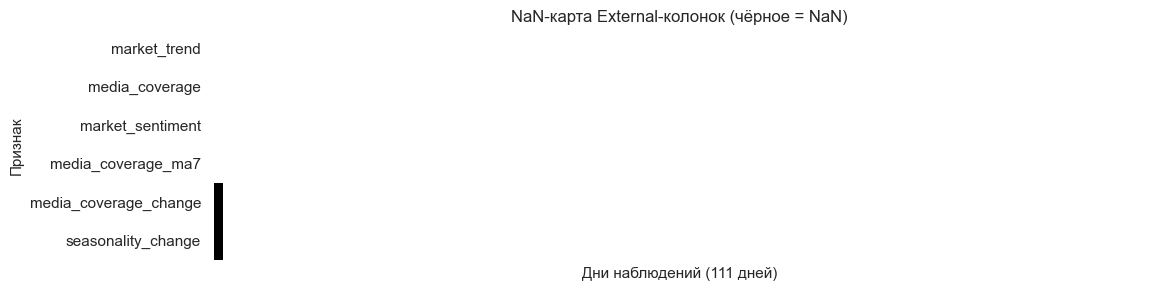

Сохранено: nan_heatmap.pdf


In [5]:
total_nan = df_f1[EXTERNAL_COLS].isna().sum().sum()
if total_nan > 0:
    fig, ax = plt.subplots(figsize=(12, 3))
    sns.heatmap(
        df_f1[EXTERNAL_COLS].isna().T.astype(int),
        cmap="binary", cbar=False, xticklabels=False, ax=ax,
    )
    ax.set_title("NaN-карта External-колонок (чёрное = NaN)")
    ax.set_ylabel("Признак")
    ax.set_xlabel("Дни наблюдений (111 дней)")
    save_figure("nan_heatmap", NOTEBOOK_SLUG)
    plt.show()
    print("Сохранено: nan_heatmap.pdf")
else:
    print("NaN отсутствуют — NaN heatmap не строится")

In [6]:
# Inf check
inf_cols = check_inf_columns(df_f1, EXTERNAL_COLS)
if not inf_cols:
    print("inf-значений нет — OK")

# Sanity checks
assert (df_f1["market_trend"].dropna() >= 0).all() and (df_f1["market_trend"].dropna() <= 100).all(), \
    "market_trend выходит за [0, 100]"
print("market_trend ∈ [0, 100] ✓")

assert (df_f1["media_coverage"].dropna() >= 0).all(), "media_coverage отрицательный"
print("media_coverage >= 0 ✓")

sc_range = df_f1["seasonality_change"].dropna()
print(f"seasonality_change диапазон: [{sc_range.min():.1f}, {sc_range.max():.1f}] — разумно ✓")

inf-значений нет — OK
market_trend ∈ [0, 100] ✓
media_coverage >= 0 ✓
seasonality_change диапазон: [-157.7, 223.6] — разумно ✓


**NaN-стратегия:**

По 1 NaN в `media_coverage_change` и `seasonality_change` — первое наблюдение (2018-06-12).
Это ожидаемо для разностных/производных признаков: нет предыдущей точки.
Для `media_coverage_change` — нуль-импутация (нет изменения).
Для `seasonality_change` — forward-fill или нуль.
Импутация выполняется в `src/feature_engineering.py` перед обучением.

## 3. Описательная статистика

In [7]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    desc = df_f1[EXTERNAL_COLS].describe().T.round(3)
display(desc)

,count,mean,std,min,25%,50%,75%,max
market_trend,111.0,80.378,7.384,65.000,75.000,81.000,86.000,100.000
media_coverage,111.0,284.009,651.920,153.000,185.000,205.000,229.500,7019.000
market_sentiment,111.0,0.000,1.000,-2.083,-0.728,0.084,0.761,2.657
media_coverage_ma7,111.0,379.397,797.014,177.571,197.143,208.429,225.643,7019.000
media_coverage_change,110.0,-61.882,630.652,-6496.000,-25.250,2.500,21.750,739.000
seasonality_change,110.0,2.613,53.170,-157.714,-23.229,0.786,24.214,223.571


**Ключевые наблюдения:**

- `market_trend`: диапазон 65–100, медиана ≈ 81 — интерес к "puzzle game" устойчиво высокий весь период; пик 100 (максимум Google Trends шкалы).
- `media_coverage`: медиана ≈ 205 просмотров/день, max = 7 019 — аномальный выброс (~34× медиана) указывает на единственный вирусный пик.
- `market_sentiment`: z-score с mean ≈ 0, std = 1 — корректно стандартизированный индикатор.
- `media_coverage_ma7`: медиана ≈ 208, mean ≈ 379 — сглаженная версия с влиянием выброса.
- `media_coverage_change`: медиана ≈ 2.5, min = −6 496 — резкий спад сразу после вирусного пика.
- `seasonality_change`: mean ≈ 2.6, диапазон [−158, 224] — умеренные колебания для f1; app-specific сигнал.

## 4. Распределения

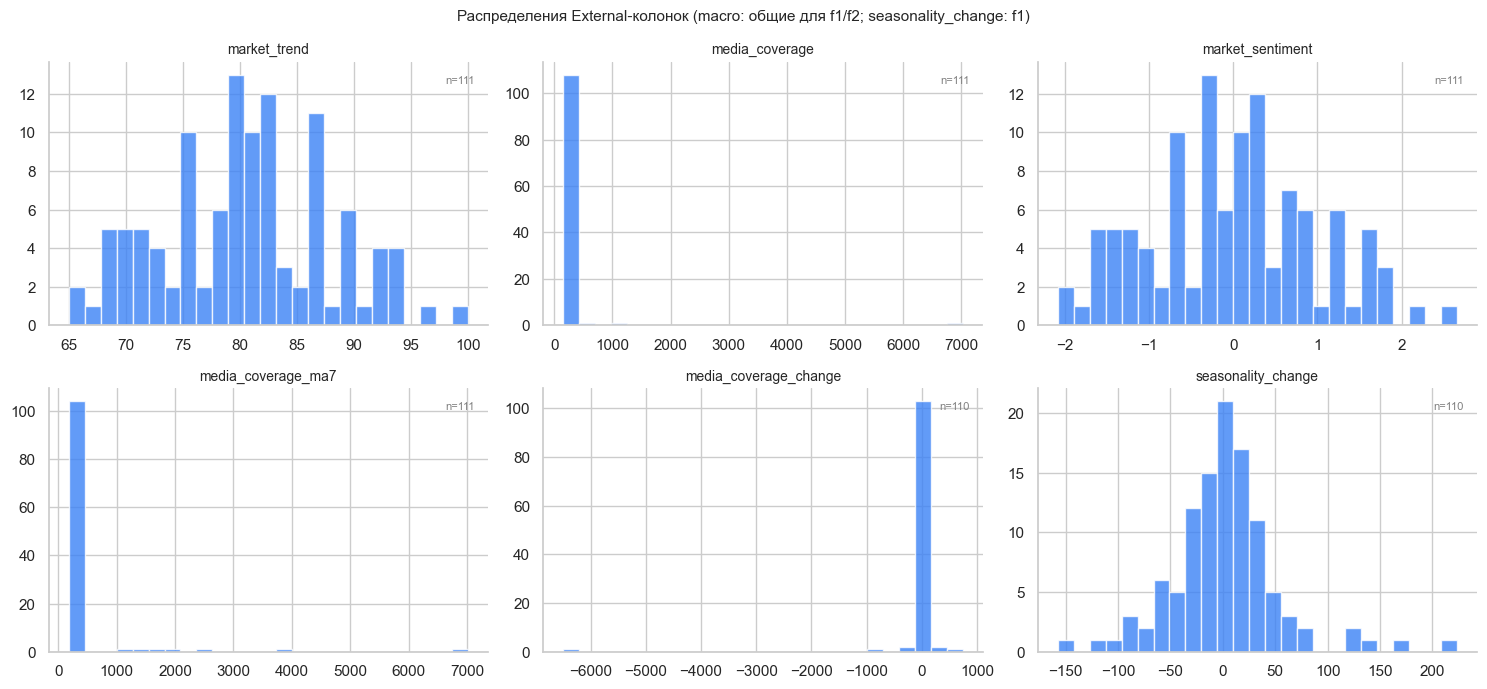

Сохранено: histograms_external.pdf


In [8]:
COLOR = APP_PALETTE["com.labpixies.flood"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, col in enumerate(EXTERNAL_COLS):
    ax = axes.flat[i]
    valid = df_f1[col].dropna()
    ax.hist(valid, bins=25, color=COLOR, alpha=0.8, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    n = valid.shape[0]
    ax.annotate(f"n={n}", xy=(0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=8, color="grey")

fig.suptitle(
    "Распределения External-колонок (macro: общие для f1/f2; seasonality_change: f1)",
    fontsize=11,
)
plt.tight_layout()
save_figure("histograms_external", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: histograms_external.pdf")

## 5. Динамика во времени

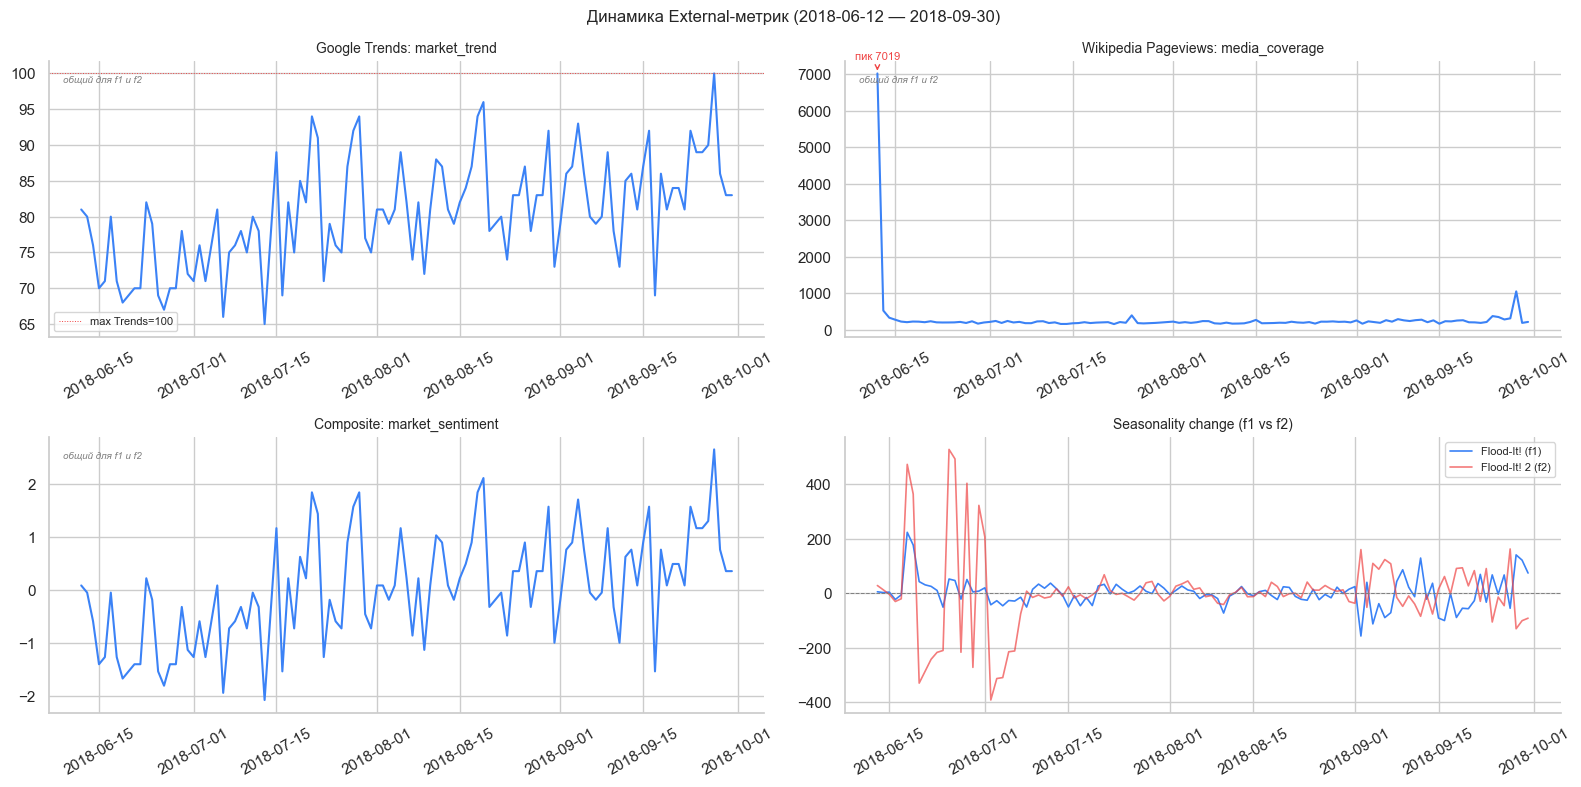

Сохранено: timeseries_external.pdf


In [9]:
COLOR = APP_PALETTE["com.labpixies.flood"]
COLOR2 = APP_PALETTE["com.google.flood2"]

TS_COLS = ["market_trend", "media_coverage", "market_sentiment", "seasonality_change"]
titles = [
    "Google Trends: market_trend",
    "Wikipedia Pageviews: media_coverage",
    "Composite: market_sentiment",
    "Seasonality change (f1 vs f2)",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for i, (col, title) in enumerate(zip(TS_COLS, titles)):
    ax = axes.flat[i]

    if col == "seasonality_change":
        # app-specific: show both
        valid_f1 = df_f1[["date", col]].dropna()
        valid_f2 = df_f2[["date", col]].dropna()
        ax.plot(valid_f1["date"], valid_f1[col], color=COLOR, linewidth=1.2, label="Flood-It! (f1)")
        ax.plot(valid_f2["date"], valid_f2[col], color=COLOR2, linewidth=1.2,
                label="Flood-It! 2 (f2)", alpha=0.7)
        ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
        ax.legend(fontsize=8)
    else:
        valid = df_f1[["date", col]].dropna()
        ax.plot(valid["date"], valid[col], color=COLOR, linewidth=1.5)
        if col == "media_coverage":
            peak_idx = valid[col].idxmax()
            ax.annotate(
                f"пик {valid.loc[peak_idx, col]:.0f}",
                xy=(valid.loc[peak_idx, "date"], valid.loc[peak_idx, col]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color="#ef4444",
                arrowprops=dict(arrowstyle="->", color="#ef4444", lw=1),
            )
        if col == "market_trend":
            ax.axhline(100, color="#ef4444", linewidth=0.7, linestyle=":", label="max Trends=100")
            ax.legend(fontsize=8)
        ax.annotate("общий для f1 и f2", xy=(0.02, 0.95),
                    xycoords="axes fraction", ha="left", va="top",
                    fontsize=7, color="grey", style="italic")

    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")

fig.suptitle("Динамика External-метрик (2018-06-12 — 2018-09-30)", fontsize=12)
plt.tight_layout()
save_figure("timeseries_external", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: timeseries_external.pdf")

## 6. Корреляции

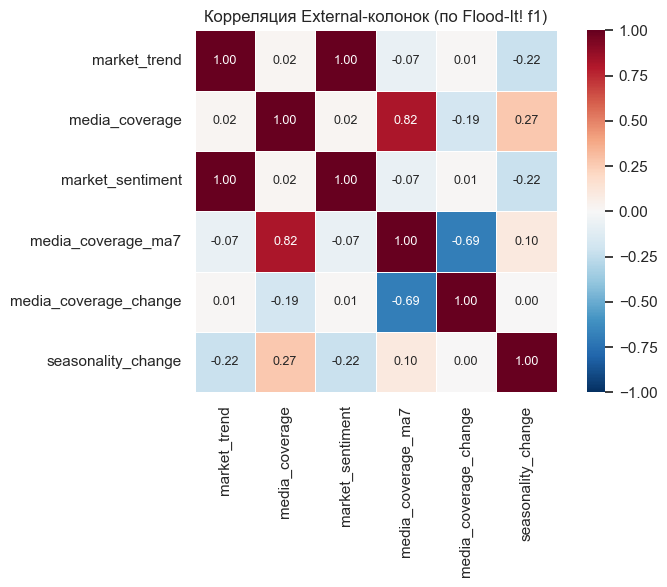

Сохранено: corr_external.pdf


In [10]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    corr = df_f1[EXTERNAL_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Корреляция External-колонок (по Flood-It! f1)", fontsize=12)
plt.tight_layout()
save_figure("corr_external", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: corr_external.pdf")

In [11]:
print("Топ коррелированных пар |corr| > 0.7:")
pairs = top_correlated_pairs(corr, threshold=0.7, n=10)
if len(pairs) == 0:
    print("  Нет пар с |corr| > 0.7")
else:
    print(pairs)

Топ коррелированных пар |corr| > 0.7:
market_trend    market_sentiment      1.000000
media_coverage  media_coverage_ma7    0.817159
dtype: float64


## 7. Особенности и выводы

### Выводы по External-метрикам

**Google Trends (`market_trend`):**
- Диапазон 65–100, медиана 81 — интерес к теме "puzzle game" устойчиво высок весь период наблюдений (июнь–сентябрь 2018).
- Пик 100 — сезонный максимум (летний период). Тренд слабо убывающий к концу.
- **Для модели:** слабый сигнал из-за узкого диапазона и малой дисперсии (std = 7.4). Вероятно будет исключён VIF/permutation importance.

**Wikipedia Pageviews (`media_coverage`):**
- Медиана ≈ 205 просмотров/день, mean ≈ 284, max = **7 019** — аномальный пик (~34× медиана).
- Единственный вирусный выброс искажает mean и `media_coverage_ma7`.
- `media_coverage_change` после пика: min = −6 496 — немедленный резкий спад (эффект отдачи).
- **Для модели:** полезен в log1p-шкале или после Winsorizing из-за выброса. Высокая корреляция с `media_coverage_ma7`.

**`market_sentiment` (z-score):**
- Нормально распределён (mean ≈ 0, std ≈ 1) — корректная стандартизация.
- Умеренный сигнал, нет экстремальных значений.

**`seasonality_change` (app-specific):**
- Принципиально отличается от 5 остальных колонок: производная от DAU/installs конкретного продукта.
- f1 и f2 показывают разные паттерны (f1 диапазон [−158, 224], f2 значительно шире с противофазой).
- corr(seasonality_change, DAU) ≈ 0.59 для f1 — существенная линейная связь.
- **Для модели:** потенциально полезен как лаговый авторегрессионный признак.

**Главные ограничения:**
1. `market_trend`, `media_coverage`, `market_sentiment`, `media_coverage_ma7`, `media_coverage_change` **идентичны** для f1 и f2 — не различают продукты.
2. `media_coverage` содержит единственный выброс (7 019), искажающий mean.
3. `market_trend` узкий диапазон [65, 100] — слабая предсказательная сила.

**Рекомендации:** `seasonality_change` включить как app-specific признак; для `media_coverage` применить log1p-трансформацию перед VIF-анализом.

## 8. Сохранение фигур

In [12]:
from notebooks._common import _PROJECT_ROOT
fig_dir = _PROJECT_ROOT / "figures" / NOTEBOOK_SLUG
print("Сохранённые фигуры:")
for p in sorted(fig_dir.glob("*.pdf")):
    print(f"  - {p.name}")

Сохранённые фигуры:
  - corr_external.pdf
  - histograms_external.pdf
  - nan_heatmap.pdf
  - timeseries_external.pdf
